In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
import warnings

In [35]:
data=pd.read_csv('Data\dataset.csv')

In [3]:
data.head()

,id,Duration in months,Credit history,Purpose of the credit,Credit amount,Status of savings account/bonds,Present employment(years),Installment rate in percentage of disposable income,personal_status,Other debtors / guarantors,...,Property,Age in years,Other installment plans (banks/stores),Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Status of existing checking account
0,1,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,2,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,3,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,4,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,5,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [36]:
X=data.drop(columns=['Status of existing checking account'],axis=1)

In [ ]:
X.head()

In [37]:
Y=data['Status of existing checking account']

In [38]:
numeric_feature=[fe for fe in data.columns if data[fe].dtype!='O']
print(len(numeric_feature),numeric_feature)
Categorical_feature=[fe for fe in data.columns if data[fe].dtype=='O']
print(len(Categorical_feature),Categorical_feature)

8 ['id', 'Duration in months', 'Credit amount', 'Installment rate in percentage of disposable income', 'Present residence since X years', 'Age in years', 'Number of existing credits at this bank', 'Number of people being liable to provide maintenance for']
13 ['Credit history', 'Purpose of the credit', 'Status of savings account/bonds', 'Present employment(years)', 'personal_status', 'Other debtors / guarantors', 'Property', 'Other installment plans (banks/stores)', 'Housing', 'Job', 'Telephone', 'Foreign worker', 'Status of existing checking account']


In [39]:
print("Categories in 'Credit history' variable:     ",end=" " )
print(data['Credit history'].unique())

print("Categories in 'Present employment(years)' variable:     ",end=" " )
print(data['Present employment(years)'].unique())

print("Categories in 'Present employment(years)' variable:     ",end=" " )
print(data['Present employment(years)'].unique())

print("Categories in 'personal_status' variable:     ",end=" " )
print(data['personal_status'].unique())

print("Categories in 'Credit history' variable:  ",end=" ")
print(data['Credit history'].unique())

print("Categories in'Purpose of the credit' variable:",end=" " )
print(data['Purpose of the credit'].unique())

print("Categories in 'Status of savings account/bonds' variable:     ",end=" " )
print(data['Status of savings account/bonds'].unique())

print("Categories in 'Present employment(years)' variable:     ",end=" " )
print(data['Present employment(years)'].unique())

Categories in 'Credit history' variable:      ['critical/other existing credit' 'existing paid' 'delayed previously'
 'no credits/all paid' 'all paid']
Categories in 'Present employment(years)' variable:      ['>=7' '1<=X<4' '4<=X<7' 'unemployed' '<1']
Categories in 'Present employment(years)' variable:      ['>=7' '1<=X<4' '4<=X<7' 'unemployed' '<1']
Categories in 'personal_status' variable:      ['male single' 'female div/dep/mar' 'male div/sep' 'male mar/wid']
Categories in 'Credit history' variable:   ['critical/other existing credit' 'existing paid' 'delayed previously'
 'no credits/all paid' 'all paid']
Categories in'Purpose of the credit' variable: ['radio/tv' 'education' 'furniture/equipment' 'new car' 'used car'
 'business' 'domestic appliance' 'repairs' 'other' 'retraining']
Categories in 'Status of savings account/bonds' variable:      ['no known savings' '<100' '500<=X<1000' '>=1000' '100<=X<500']
Categories in 'Present employment(years)' variable:      ['>=7' '1<=X<4' '4<=

In [40]:
Y_encoded = Y.map({'bad': 0, 'good': 1})

In [41]:
Y_encoded 

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Status of existing checking account, Length: 1000, dtype: int64

In [ ]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns
#Y_feature=Y.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [42]:
X = preprocessor.fit_transform(X)


In [32]:
Y=pd.get_dummies(Y)

In [43]:
Y

0      good
1       bad
2      good
3      good
4       bad
       ... 
995    good
996    good
997    good
998     bad
999    good
Name: Status of existing checking account, Length: 1000, dtype: object

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y_encoded,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 58), (200, 58))

Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable


'conda' is not recognized as an internal or external command,
operable program or batch file.


In [61]:
from imblearn.under_sampling import RandomUnderSampler

# Check class distribution
print("Before Balancing:", Counter(y_train))

# Apply Random Undersampling
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

# Check new class distribution
print("After Balancing:", Counter(y_resampled))


ModuleNotFoundError: No module named 'imblearn'

In [45]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "logestic_regration": LogisticRegression,
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)  
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.4049
- Mean Absolute Error: 0.3367
- R2 Score: 0.2212
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4180
- Mean Absolute Error: 0.3492
- R2 Score: 0.1600




AttributeError: 'numpy.ndarray' object has no attribute '_validate_params'

In [47]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.165939
0,Linear Regression,0.159985
7,CatBoosting Regressor,0.152139
5,Random Forest Regressor,0.093143
8,AdaBoost Regressor,0.076861
6,XGBRegressor,0.046108
3,K-Neighbors Regressor,0.026806
1,Lasso,-0.000188
4,Decision Tree,-0.971391


In [48]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 16.00


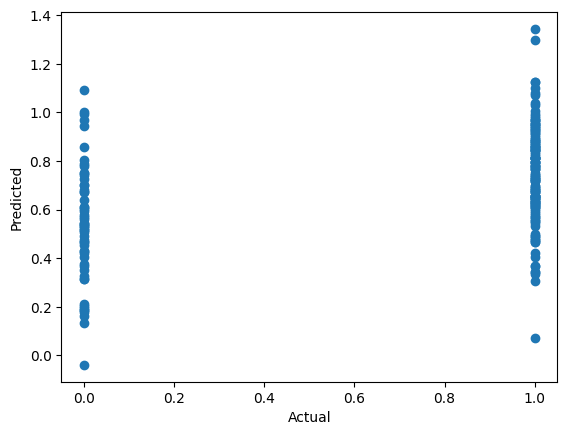

In [49]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

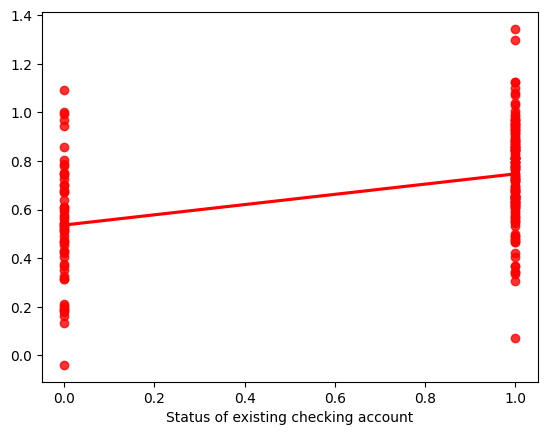

In [50]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [51]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,0,0.726562,-0.726562
737,1,0.570312,0.429688
740,1,0.335938,0.664062
660,1,0.609375,0.390625
411,1,0.937500,0.062500
...,...,...,...
408,1,0.765625,0.234375
332,0,0.187500,-0.187500
208,1,0.476562,0.523438
613,1,0.484375,0.515625


In [52]:
sum(Y_encoded)/len(Y_encoded)

0.7